# 分层索引用于RAG

本笔记为RAG系统实现了一种分层索引方法。该技术通过使用两级搜索方法来改进检索：首先通过摘要识别相关的文档部分，然后从这些部分检索具体细节。

传统的RAG方法对所有文本片段一视同仁，这可能导致：

- 当片段过小时丢失上下文
- 当文档集合较大时产生不相关的结果
- 在整个语料库中进行低效的搜索

分层检索通过以下方式解决了这些问题：

- 为较大的文档部分创建简洁的摘要
- 首先搜索这些摘要以识别相关部分
- 然后仅从这些部分检索详细信息
- 在保留具体细节的同时维护上下文

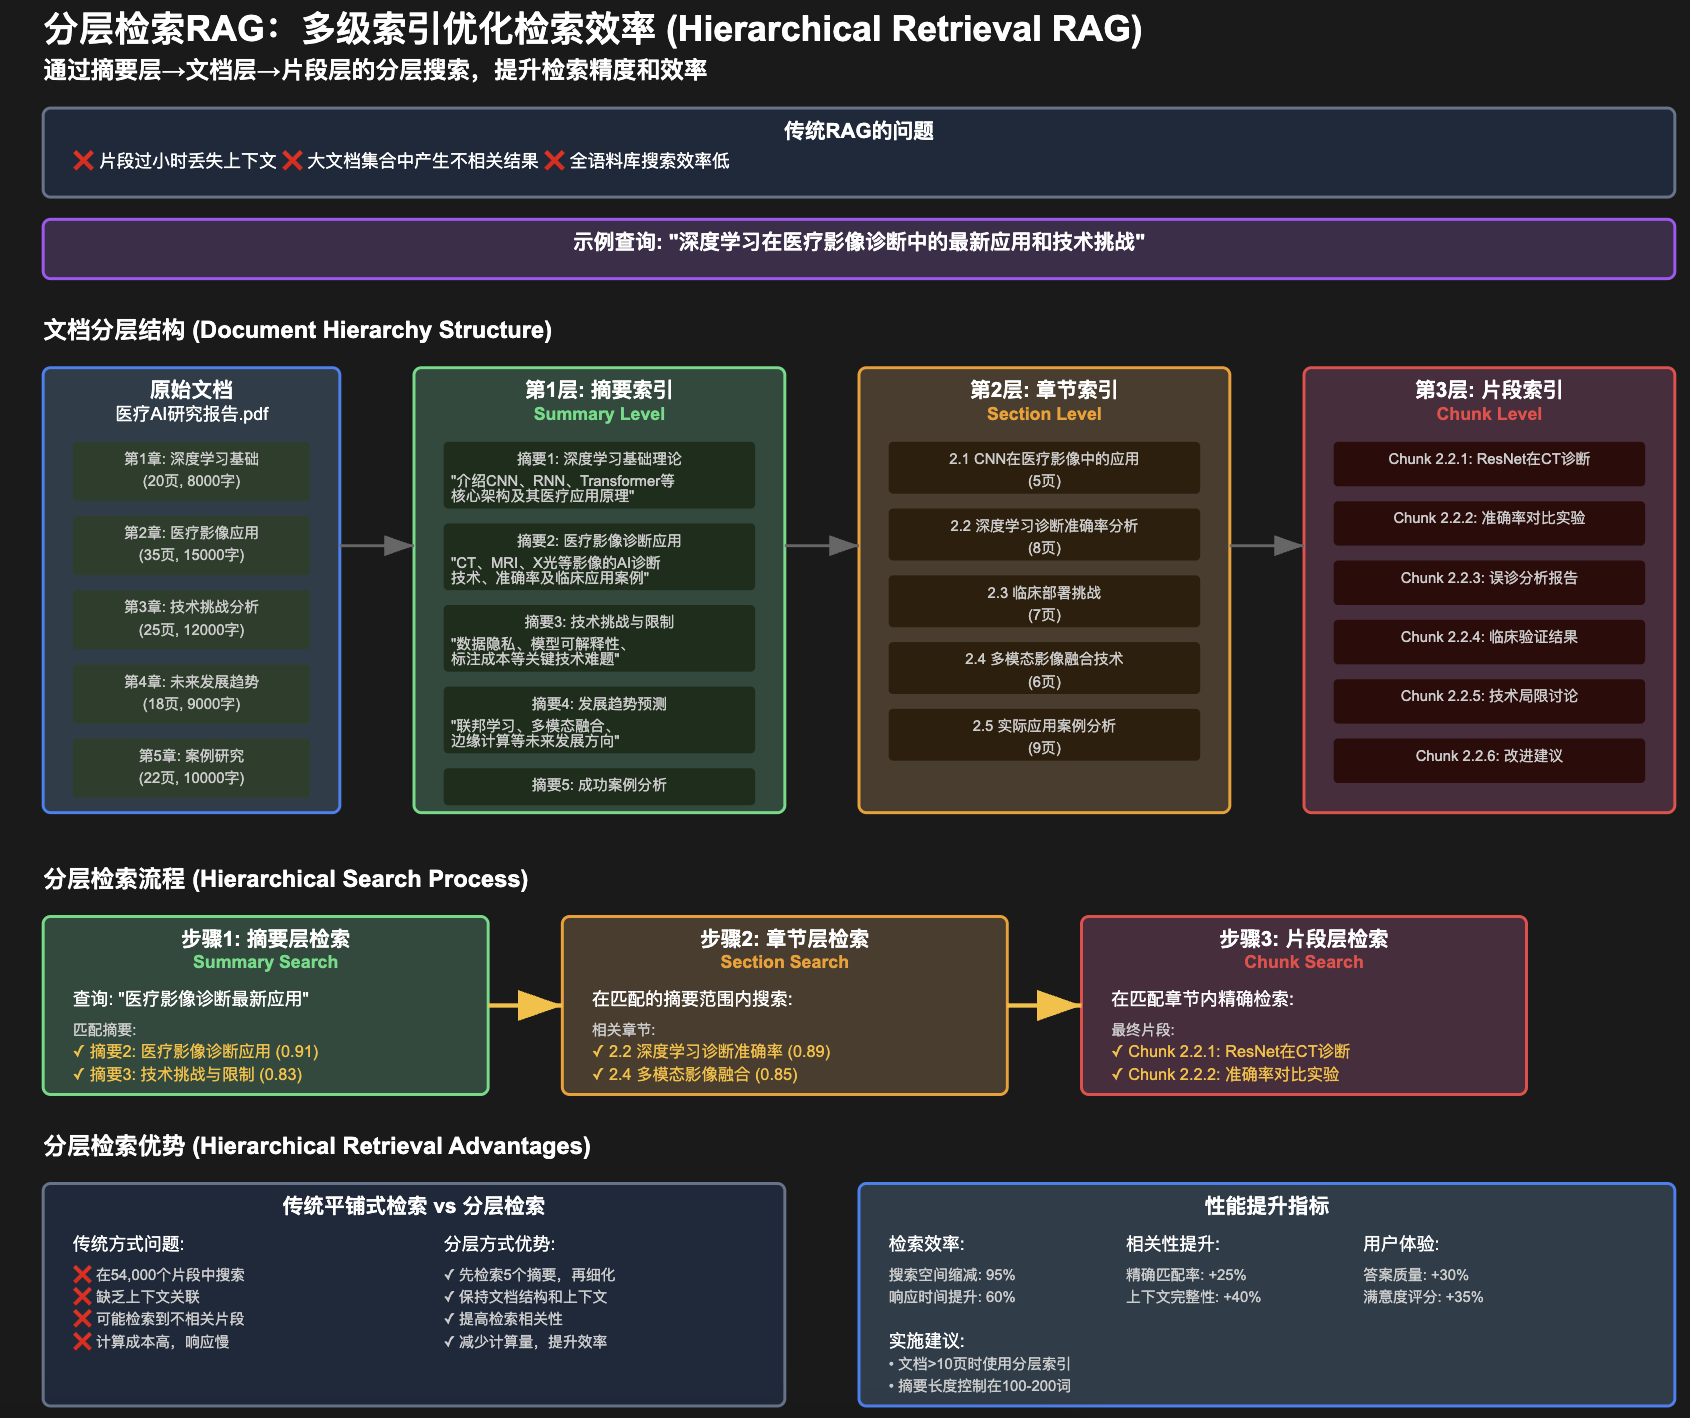

## 环境设置  
我们首先导入必要的库。

In [1]:
import os
import numpy as np
import json
import fitz  # PyMuPDF库，用于处理PDF文件
from openai import OpenAI  # OpenAI API客户端
import re  # 正则表达式模块
import pickle  # 用于序列化和反序列化Python对象

## 设置OpenAI API客户端
我们初始化OpenAI客户端以生成嵌入向量和回复。

In [2]:
from dotenv import load_dotenv

load_dotenv()  # 加载.env文件
api_key = os.getenv("DASHSCOPE_API_KEY")  # 读取密钥
base_url = os.getenv("base_url")
# 初始化 OpenAI 客户端，设置基础 URL 和 API 密钥
client = OpenAI(
    base_url=base_url,
    api_key=api_key,  # 从环境变量中获取 API 密钥
)


## 文档处理功能

In [3]:
def extract_text_from_pdf(pdf_path):
    """
    从PDF文件中提取文本内容，并按页分离。

    参数:
        pdf_path (str): PDF文件的路径

    返回:
        List[Dict]: 包含文本内容和元数据的页面列表
    """
    print(f"Extracting text from {pdf_path}...") # 打印正在处理的PDF文件路径
    pdf = fitz.open(pdf_path)  # 使用PyMuPDF打开PDF文件
    pages = []  # 初始化一个空列表用于存储包含文本内容的页面

    # 遍历PDF中的每一页
    for page_num in range(len(pdf)):
        page = pdf[page_num]  # 获取当前页
        text = page.get_text()  # 从当前页提取文本

        # 跳过文本量非常少（少于50个字符）的页面
        if len(text.strip()) > 50:
            # 将页面文本和元数据追加到列表中
            pages.append({
                "text": text,
                "metadata": {
                    "source": pdf_path,  # 源文件路径
                    "page": page_num + 1  # 页码（基于1的索引）
                }
            })
    
    print(f"Extracted {len(pages)} pages with content")  # 打印提取的有内容的页面数量
    return pages  # 返回包含文本内容和元数据的页面列表

In [4]:
def chunk_text(text, metadata, chunk_size=1000, overlap=200):
    """
    将文本分割为重叠的片段并保留元数据。
    
    参数:
        text (str): 要分割的输入文本
        metadata (Dict): 要保留的元数据
        chunk_size (int): 每个片段的字符数
        overlap (int): 片段之间的重叠字符数
        
    返回:
        List[Dict]: 带有元数据的文本片段列表
    """
    chunks = []  # 初始化一个空列表以存储片段
    
    # 使用指定的片段大小和重叠值迭代文本
    for i in range(0, len(text), chunk_size - overlap):
        chunk_text = text[i:i + chunk_size]  # 提取文本片段
        
        # 跳过非常小的片段（少于50个字符）
        if chunk_text and len(chunk_text.strip()) > 50:
            # 创建元数据的副本并添加片段特定的信息
            chunk_metadata = metadata.copy()
            chunk_metadata.update({
                "chunk_index": len(chunks),  # 片段索引
                "start_char": i,  # 片段起始字符索引
                "end_char": i + len(chunk_text),  # 片段结束字符索引
                "is_summary": False  # 标志位，表示这不是摘要
            })
            
            # 将片段及其元数据追加到列表中
            chunks.append({
                "text": chunk_text,
                "metadata": chunk_metadata
            })
    
    return chunks  # 返回带有元数据的片段列表

## 简单向量存储实现

In [5]:
class SimpleVectorStore:
    """
    一个使用NumPy实现的简单向量存储。
    """
    def __init__(self):
        self.vectors = []  # 存储向量嵌入的列表
        self.texts = []  # 存储文本内容的列表
        self.metadata = []  # 存储元数据的列表
    
    def add_item(self, text, embedding, metadata=None):
        """
        向向量存储中添加一个条目。
        
        参数:
            text (str): 文本内容
            embedding (List[float]): 向量嵌入
            metadata (Dict, 可选): 额外的元数据
        """
        self.vectors.append(np.array(embedding))  # 将嵌入作为numpy数组追加
        self.texts.append(text)  # 追加文本内容
        self.metadata.append(metadata or {})  # 追加元数据或空字典（如果为None）
    
    def similarity_search(self, query_embedding, k=5, filter_func=None):
        """
        查找与查询嵌入最相似的条目。
        
        参数:
            query_embedding (List[float]): 查询嵌入向量
            k (int): 返回结果的数量
            filter_func (可调用对象, 可选): 用于过滤结果的函数
        
        返回:
            List[Dict]: 最相似的前k个条目
        """
        if not self.vectors:
            return []  # 如果没有向量，则返回空列表
        
        # 将查询嵌入转换为numpy数组
        query_vector = np.array(query_embedding)
        
        # 使用余弦相似度计算相似性
        similarities = []
        for i, vector in enumerate(self.vectors):
            # 如果不符合过滤条件则跳过
            if filter_func and not filter_func(self.metadata[i]):
                continue
                
            # 计算余弦相似度
            similarity = np.dot(query_vector, vector) / (np.linalg.norm(query_vector) * np.linalg.norm(vector))
            similarities.append((i, similarity))  # 追加索引和相似度分数
        
        # 按相似度降序排序
        similarities.sort(key=lambda x: x[1], reverse=True)
        
        # 返回前k个结果
        results = []
        for i in range(min(k, len(similarities))):
            idx, score = similarities[i]
            results.append({
                "text": self.texts[idx],  # 添加文本内容
                "metadata": self.metadata[idx],  # 添加元数据
                "similarity": float(score)  # 添加相似度分数
            })
        
        return results  # 返回前k个结果的列表

## 创建嵌入（Embeddings）

In [6]:
def create_embeddings(text, model="text-embedding-v4"):
    """
    使用指定的模型为给定文本创建嵌入。

    参数:
    text (str): 需要创建嵌入的输入文本。
    model (str): 用于创建嵌入的模型。

    返回:
    List[float]: 嵌入向量。
    """
    # 1. 统一转换为列表进行批处理计算
    input_text = [text] if isinstance(text, str) else text

    max_batch_size = 10
    all_embeddings = []

    # 2. 按照每 10 个一组进行分批请求，避免触发 API 限制
    for i in range(0, len(input_text), max_batch_size):
        batch = input_text[i : i + max_batch_size]
        response = client.embeddings.create(model=model, input=batch)
        # 将当前批次的结果提取并合并
        all_embeddings.extend([item.embedding for item in response.data])

    # 3. 严格遵循原有的返回逻辑：
    # 如果输入是字符串，则返回第一个嵌入向量 (List[float])
    if isinstance(text, str):
        return all_embeddings[0]

    # 否则，返回所有嵌入向量的列表 (List[List[float]])
    return all_embeddings


## 摘要功能

In [7]:
def generate_page_summary(page_text):
    """
    生成页面的简洁摘要。

    参数:
        page_text (str): 页面的文本内容

    返回:
        str: 生成的摘要
    """
    # 定义系统提示以指导摘要模型
    system_prompt = """You are an expert summarization system.
    Create a detailed summary of the provided text. 
    Focus on capturing the main topics, key information, and important facts.
    Your summary should be comprehensive enough to understand what the page contains
    but more concise than the original."""

    # 如果输入文本超过最大标记限制，则截断文本
    max_tokens = 6000
    truncated_text = page_text[:max_tokens] if len(page_text) > max_tokens else page_text

    # 向OpenAI API 发出请求以生成摘要
    response = client.chat.completions.create(
        model="qwen-plus",  # 指定要使用的模型
        messages=[
            {"role": "system", "content": system_prompt},  # 系统消息以引导助手
            {"role": "user", "content": f"Please summarize this text:\n\n{truncated_text}"}  # 用户消息，包含要总结的文本
        ],
        temperature=0.3  # 设置回复生成的温度
    )

    # 返回生成的摘要内容
    return response.choices[0].message.content

## 分层文档处理

In [8]:
def process_document_hierarchically(pdf_path, chunk_size=1000, chunk_overlap=200):
    """
    将文档处理为分层索引。

    参数:
        pdf_path (str): PDF文件的路径
        chunk_size (int): 每个详细块的大小
        chunk_overlap (int): 块之间的重叠部分

    返回:
        Tuple[SimpleVectorStore, SimpleVectorStore]: 摘要和详细的向量存储
    """
    # 从PDF中提取页面
    pages = extract_text_from_pdf(pdf_path)
    
    # 为每一页创建摘要
    print("Generating page summaries...")
    summaries = []
    for i, page in enumerate(pages):
        print(f"Summarizing page {i+1}/{len(pages)}...")
        summary_text = generate_page_summary(page["text"])
        
        # 创建摘要元数据
        summary_metadata = page["metadata"].copy()
        summary_metadata.update({"is_summary": True})
        
        # 将摘要文本和元数据追加到摘要列表中
        summaries.append({
            "text": summary_text,
            "metadata": summary_metadata
        })
    
    # 为每一页创建详细的块
    detailed_chunks = []
    for page in pages:
        # 对页面的文本进行分块
        page_chunks = chunk_text(
            page["text"], 
            page["metadata"], 
            chunk_size, 
            chunk_overlap
        )
        # 使用当前页面的块扩展详细的块列表
        detailed_chunks.extend(page_chunks)
    
    print(f"Created {len(detailed_chunks)} detailed chunks")
    
    # 为摘要创建嵌入
    print("Creating embeddings for summaries...")
    summary_texts = [summary["text"] for summary in summaries]
    summary_embeddings = create_embeddings(summary_texts)
    
    # 为详细的块创建嵌入
    print("Creating embeddings for detailed chunks...")
    chunk_texts = [chunk["text"] for chunk in detailed_chunks]
    chunk_embeddings = create_embeddings(chunk_texts)
    
    # 创建向量存储
    summary_store = SimpleVectorStore()
    detailed_store = SimpleVectorStore()
    
    # 向摘要存储中添加摘要
    for i, summary in enumerate(summaries):
        summary_store.add_item(
            text=summary["text"],
            embedding=summary_embeddings[i],
            metadata=summary["metadata"]
        )
    
    # 向详细的存储中添加块
    for i, chunk in enumerate(detailed_chunks):
        detailed_store.add_item(
            text=chunk["text"],
            embedding=chunk_embeddings[i],
            metadata=chunk["metadata"]
        )
    
    print(f"Created vector stores with {len(summaries)} summaries and {len(detailed_chunks)} chunks")
    return summary_store, detailed_store

## 层次检索

In [9]:
def retrieve_hierarchically(query, summary_store, detailed_store, k_summaries=3, k_chunks=5):
    """
    使用分层索引检索信息。
    
    参数:
        query (str): 用户查询
        summary_store (SimpleVectorStore): 文档摘要存储
        detailed_store (SimpleVectorStore): 详细片段存储
        k_summaries (int): 要检索的摘要数量
        k_chunks (int): 每个摘要要检索的片段数量
        
    返回:
        List[Dict]: 带有相关性分数的检索片段
    """
    print(f"Performing hierarchical retrieval for query: {query}")
    
    # 创建查询嵌入
    query_embedding = create_embeddings(query)
    
    # 首先，检索相关的摘要
    summary_results = summary_store.similarity_search(
        query_embedding, 
        k=k_summaries
    )
    
    print(f"Retrieved {len(summary_results)} relevant summaries")
    
    # 从相关摘要中收集页面
    relevant_pages = [result["metadata"]["page"] for result in summary_results]
    
    # 创建一个过滤函数，仅保留来自相关页面的片段
    def page_filter(metadata):
        return metadata["page"] in relevant_pages
    
    # 然后，仅从这些相关的页面中检索详细的片段
    detailed_results = detailed_store.similarity_search(
        query_embedding, 
        k=k_chunks * len(relevant_pages),
        filter_func=page_filter
    )
    
    print(f"Retrieved {len(detailed_results)} detailed chunks from relevant pages")
    
    # 对于每个结果，添加它来自哪个摘要/页面
    for result in detailed_results:
        page = result["metadata"]["page"]
        matching_summaries = [s for s in summary_results if s["metadata"]["page"] == page]
        if matching_summaries:
            result["summary"] = matching_summaries[0]["text"]
    
    return detailed_results

## 带上下文的回复生成

In [10]:
def generate_response(query, retrieved_chunks):
    """
    根据查询和检索到的块生成回复。

    参数:
        query (str): 用户查询
        retrieved_chunks (List[Dict]): 来自分层搜索的检索块

    返回:
        str: 生成的回复
    """
    # 从块中提取文本并准备上下文部分
    context_parts = []
    
    for i, chunk in enumerate(retrieved_chunks):
        page_num = chunk["metadata"]["page"]  # 从元数据中获取页码
        context_parts.append(f"[Page {page_num}]: {chunk['text']}")  # 使用页码格式化块文本
    
    # 将所有上下文部分组合成单个上下文字符串
    context = "\n\n".join(context_parts)
    
    # 定义系统消息以指导AI助手
    system_message = """You are a helpful AI assistant answering questions based on the provided context.
Use the information from the context to answer the user's question accurately.
If the context doesn't contain relevant information, acknowledge that.
Include page numbers when referencing specific information."""

    # 使用OpenAI API生成回复
    response = client.chat.completions.create(
        model="qwen-plus",  # 指定要使用的模型
        messages=[
            {"role": "system", "content": system_message},  # 系统消息以指导助手
            {"role": "user", "content": f"Context:\n\n{context}\n\nQuestion: {query}"}  # 用户消息包含上下文和查询
        ],
        temperature=0.2  # 设置回复生成的温度
    )
    
    # 返回生成的回复内容
    return response.choices[0].message.content

## 完整的RAG管道与分层检索

In [11]:
def hierarchical_rag(query, pdf_path, chunk_size=1000, chunk_overlap=200, 
                    k_summaries=3, k_chunks=5, regenerate=False):
    """
    完整的分层RAG管道。

    参数:
        query (str): 用户查询
        pdf_path (str): PDF文档的路径
        chunk_size (int): 每个详细块的大小
        chunk_overlap (int): 块之间的重叠部分
        k_summaries (int): 要检索的摘要数量
        k_chunks (int): 每个摘要要检索的块数量
        regenerate (bool): 是否重新生成向量存储

    返回:
        Dict: 结果字典，包括回复和检索到的块
    """
    # 创建存储文件名以进行缓存
    summary_store_file = f"{os.path.basename(pdf_path)}_summary_store.pkl"
    detailed_store_file = f"{os.path.basename(pdf_path)}_detailed_store.pkl"
    
    # 如果需要处理文档并创建存储，请执行以下操作
    if regenerate or not os.path.exists(summary_store_file) or not os.path.exists(detailed_store_file):
        print("Processing document and creating vector stores...")
        # 处理文档以创建分层索引和向量存储
        summary_store, detailed_store = process_document_hierarchically(
            pdf_path, chunk_size, chunk_overlap
        )
        
        # 将摘要存储保存到文件中以供将来使用
        with open(summary_store_file, 'wb') as f:
            pickle.dump(summary_store, f)
        
        # 将详细存储保存到文件中以供将来使用
        with open(detailed_store_file, 'wb') as f:
            pickle.dump(detailed_store, f)
    else:
        # 从文件加载现有的摘要存储
        print("Loading existing vector stores...")
        with open(summary_store_file, 'rb') as f:
            summary_store = pickle.load(f)
        
        # 从文件加载现有的详细存储
        with open(detailed_store_file, 'rb') as f:
            detailed_store = pickle.load(f)
    
    # 使用查询基于层次结构检索相关的块
    retrieved_chunks = retrieve_hierarchically(
        query, summary_store, detailed_store, k_summaries, k_chunks
    )
    
    # 根据检索到的块生成回复
    response = generate_response(query, retrieved_chunks)
    
    # 返回结果字典，包括查询、回复、检索到的块以及摘要和详细块的数量
    return {
        "query": query,
        "response": response,
        "retrieved_chunks": retrieved_chunks,
        "summary_count": len(summary_store.texts),
        "detailed_count": len(detailed_store.texts)
    }

## 对比用的标准（非分层）RAG

In [12]:
def standard_rag(query, pdf_path, chunk_size=1000, chunk_overlap=200, k=15):
    """
    标准RAG管道，不使用分层检索。
    
    参数:
        query (str): 用户查询
        pdf_path (str): PDF文档的路径
        chunk_size (int): 每个块的大小
        chunk_overlap (int): 块之间的重叠部分
        k (int): 要检索的块的数量
        
    返回:
        Dict: 包括回复和检索到的块的结果字典
    """
    # 从PDF文档中提取页面
    pages = extract_text_from_pdf(pdf_path)
    
    # 直接从所有页面创建块
    chunks = []
    for page in pages:
        # 对页面文本进行分块
        page_chunks = chunk_text(
            page["text"], 
            page["metadata"], 
            chunk_size, 
            chunk_overlap
        )
        # 使用当前页面的块扩展块列表
        chunks.extend(page_chunks)
    
    print(f"Created {len(chunks)} chunks for standard RAG")
    
    # 创建一个向量存储来保存块
    store = SimpleVectorStore()
    
    # 为块创建嵌入
    print("Creating embeddings for chunks...")
    texts = [chunk["text"] for chunk in chunks]
    embeddings = create_embeddings(texts)
    
    # 将块添加到向量存储中
    for i, chunk in enumerate(chunks):
        store.add_item(
            text=chunk["text"],
            embedding=embeddings[i],
            metadata=chunk["metadata"]
        )
    
    # 为查询创建嵌入
    query_embedding = create_embeddings(query)
    
    # 基于查询嵌入检索最相关的块
    retrieved_chunks = store.similarity_search(query_embedding, k=k)
    print(f"Retrieved {len(retrieved_chunks)} chunks with standard RAG")
    
    # 基于检索到的块生成回复
    response = generate_response(query, retrieved_chunks)
    
    # 返回包括查询、回复和检索到的块的结果
    return {
        "query": query,
        "response": response,
        "retrieved_chunks": retrieved_chunks
    }

## 评估函数

In [13]:
def compare_approaches(query, pdf_path, reference_answer=None):
    """
    比较分层和标准RAG方法。

    参数:
        query (str): 用户查询
        pdf_path (str): PDF文档的路径
        reference_answer (str, optional): 用于评估的参考答案

    返回:
        Dict: 比较结果
    """
    print(f"\n=== Comparing RAG approaches for query: {query} ===")
    
    # 运行分层RAG
    print("\nRunning hierarchical RAG...")
    hierarchical_result = hierarchical_rag(query, pdf_path)
    hier_response = hierarchical_result["response"]
    
    # 运行标准RAG
    print("\nRunning standard RAG...")
    standard_result = standard_rag(query, pdf_path)
    std_response = standard_result["response"]
    
    # 比较分层RAG和标准RAG的结果
    comparison = compare_responses(query, hier_response, std_response, reference_answer)
    
    # 返回包含比较结果的字典
    return {
        "query": query,  # 原始查询
        "hierarchical_response": hier_response,  # 分层RAG的回复
        "standard_response": std_response,  # 标准RAG的回复
        "reference_answer": reference_answer,  # 用于评估的参考答案
        "comparison": comparison,  # 比较分析
        "hierarchical_chunks_count": len(hierarchical_result["retrieved_chunks"]),  # 分层RAG检索到的块数
        "standard_chunks_count": len(standard_result["retrieved_chunks"])  # 标准RAG检索到的块数
    }

In [14]:
def compare_responses(query, hierarchical_response, standard_response, reference=None):
    """
    比较来自分层和标准RAG的回复。

    参数:
        query (str): 用户查询
        hierarchical_response (str): 分层RAG生成的回复
        standard_response (str): 标准RAG生成的回复
        reference (str, optional): 参考答案

    返回:
        str: 比较分析结果
    """
    # 定义系统提示，指导模型如何评估这些回复
    system_prompt = """You are an expert evaluator of information retrieval systems. 
Compare the two responses to the same query, one generated using hierarchical retrieval
and the other using standard retrieval.

Evaluate them based on:
1. Accuracy: Which response provides more factually correct information?
2. Comprehensiveness: Which response better covers all aspects of the query?
3. Coherence: Which response has better logical flow and organization?
4. Page References: Does either response make better use of page references?

Be specific in your analysis of the strengths and weaknesses of each approach."""

    # 创建用户提示，包含查询和两种回复
    user_prompt = f"""Query: {query}

Response from Hierarchical RAG:
{hierarchical_response}

Response from Standard RAG:
{standard_response}"""

    # 如果提供了参考答案，则将其包含在用户提示中
    if reference:
        user_prompt += f"""

Reference Answer:
{reference}"""

    # 在用户提示中添加最后的指令
    user_prompt += """

Please provide a detailed comparison of these two responses, highlighting which approach performed better and why."""

    # 向OpenAI API 发起请求以生成比较分析
    response = client.chat.completions.create(
        model="qwen-plus",
        messages=[
            {"role": "system", "content": system_prompt},  # 系统消息以引导助手
            {"role": "user", "content": user_prompt}  # 用户消息，包含查询和回复
        ],
        temperature=0  # 设置回复生成的温度参数
    )
    
    # 返回生成的比较分析结果
    return response.choices[0].message.content

In [15]:
def run_evaluation(pdf_path, test_queries, reference_answers=None):
    """
    执行包含多个测试查询的完整评估。
    
    参数:
        pdf_path (str): PDF 文档的路径
        test_queries (List[str]): 测试查询的列表
        reference_answers (List[str], 可选): 查询的参考答案
        
    返回:
        Dict: 评估结果
    """
    results = []  # 初始化一个空列表以存储结果
    
    # 遍历每个测试查询
    for i, query in enumerate(test_queries):
        print(f"Query: {query}")  # 打印当前查询
        
        # 如果有参考答案，则获取
        reference = None
        if reference_answers and i < len(reference_answers):
            reference = reference_answers[i]  # 获取当前查询的参考答案
        
        # 比较层次化和标准 RAG 方法
        result = compare_approaches(query, pdf_path, reference)
        results.append(result)  # 将结果追加到结果列表中
    
    # 生成评估结果的整体分析
    overall_analysis = generate_overall_analysis(results)
    
    return {
        "results": results,  # 返回单个结果
        "overall_analysis": overall_analysis  # 返回整体分析
    }

In [16]:
def generate_overall_analysis(results):
    """
    生成对评估结果的整体分析。
    
    参数:
        results (List[Dict]): 来自单个查询评估的结果
        
    返回:
        str: 整体分析
    """
    # 定义系统提示，指导模型如何评估结果
    system_prompt = """You are an expert at evaluating information retrieval systems.
Based on multiple test queries, provide an overall analysis comparing hierarchical RAG 
with standard RAG.

Focus on:
1. When hierarchical retrieval performs better and why
2. When standard retrieval performs better and why
3. The overall strengths and weaknesses of each approach
4. Recommendations for when to use each approach"""

    # 创建评估的摘要
    evaluations_summary = ""
    for i, result in enumerate(results):
        evaluations_summary += f"Query {i+1}: {result['query']}\n"
        evaluations_summary += f"Hierarchical chunks: {result['hierarchical_chunks_count']}, Standard chunks: {result['standard_chunks_count']}\n"
        evaluations_summary += f"Comparison summary: {result['comparison'][:200]}...\n\n"

    # 定义带有评估摘要的用户提示
    user_prompt = f"""Based on the following evaluations comparing hierarchical vs standard RAG across {len(results)} queries, 
provide an overall analysis of these two approaches:

{evaluations_summary}

Please provide a comprehensive analysis of the relative strengths and weaknesses of hierarchical RAG 
compared to standard RAG, with specific focus on retrieval quality and response generation."""

    # 向OpenAI API 发起请求以生成整体分析
    response = client.chat.completions.create(
        model="qwen-plus",
        messages=[
            {"role": "system", "content": system_prompt},  # 系统消息以引导助手
            {"role": "user", "content": user_prompt}  # 用户消息包含评估摘要
        ],
        temperature=0  # 设置回复生成的温度
    )
    
    # 返回生成的整体分析
    return response.choices[0].message.content

## 层次化与标准RAG方法的评估

In [17]:
# PDF 文档中包含 AI 信息的路径  
pdf_path = "data/AI_Information.pdf"  

# 测试分层 RAG 方法的示例查询关于 AI 的问题  
query = "What are the key applications of transformer models in natural language processing?"
result = hierarchical_rag(query, pdf_path)

print("\n=== Response ===")
print(result["response"])

# 用于正式评估的测试查询（按照要求仅使用一个查询）  
test_queries = [
    "How do transformers handle sequential data compared to RNNs?"
]

# 为测试查询提供的参考答案以便进行比较  
reference_answers = [
    "Transformers handle sequential data differently from RNNs by using self-attention mechanisms instead of recurrent connections. This allows transformers to process all tokens in parallel rather than sequentially, capturing long-range dependencies more efficiently and enabling better parallelization during training. Unlike RNNs, transformers don't suffer from vanishing gradient problems with long sequences."
]

# 运行评估，比较分层和标准 RAG 方法  
evaluation_results = run_evaluation(  
    pdf_path=pdf_path,  
    test_queries=test_queries,  
    reference_answers=reference_answers  
)  

# 打印比较的整体分析  
print("\n=== OVERALL ANALYSIS ===")
print(evaluation_results["overall_analysis"])

Processing document and creating vector stores...
Extracting text from data/AI_Information.pdf...
Extracted 15 pages with content
Generating page summaries...
Summarizing page 1/15...
Summarizing page 2/15...
Summarizing page 3/15...
Summarizing page 4/15...
Summarizing page 5/15...
Summarizing page 6/15...
Summarizing page 7/15...
Summarizing page 8/15...
Summarizing page 9/15...
Summarizing page 10/15...
Summarizing page 11/15...
Summarizing page 12/15...
Summarizing page 13/15...
Summarizing page 14/15...
Summarizing page 15/15...
Created 47 detailed chunks
Creating embeddings for summaries...
Creating embeddings for detailed chunks...
Created vector stores with 15 summaries and 47 chunks
Performing hierarchical retrieval for query: What are the key applications of transformer models in natural language processing?
Retrieved 3 relevant summaries
Retrieved 11 detailed chunks from relevant pages

=== Response ===
The provided context does not mention **transformer models** or describe

你好！我是你的AI研究员与工程导师。你提供的这份关于**RAG分层索引（Hierarchical Indexing）**的提纲非常有价值。分层检索是目前解决长文本、复杂文档QA（问答）的最有效手段之一。

为了让你不仅能懂，还能马上在代码仓库里实现它，我将严格按照你的要求，为你剥茧抽丝，把这个技术彻底讲透。

---

# 📚 深度解析：面向RAG系统的分层索引架构

根据你的提纲，我们将整个技术体系拆解为两个核心模块：**传统RAG的痛点** 与 **分层检索的破局之道**。

---

## 提纲点一：传统RAG方法的局限性（为什么要引入分层？）

提纲提到传统RAG对所有片段一视同仁，导致“上下文丢失”、“产生不相关结果”、“低效搜索”。我们先来看看为什么会这样。

### （1）直观理解（Intuition）
想象你把一本1000页的《红楼梦》送进碎纸机，切成了几万张小纸条（Chunks），然后全混在一起洒在地上。
现在有人问你：“林黛玉进贾府时穿了什么？”
你用传统RAG去纸条堆里找，找到了几张带有“林黛玉”、“穿”的纸条。但你发现，由于纸条太小，你不知道这到底是在写“进贾府”，还是“葬花”，还是“抄检大观园”时的场景。**你找到了词，但弄丢了故事脉络（上下文）。**

### （2）核心原理：Chunk Size 的“测不准原理”
传统RAG的设计存在一个根本的工程矛盾（Trade-off）：
* **切片过小（如 200 tokens）：** 向量表达非常聚焦，能精准命中细节。但缺乏全局语境。比如某片段只有“他拿起了剑”，模型根本不知道“他”是谁。
* **切片过大（如 2000 tokens）：** 包含了完整的上下文。但一段文本里包含了太多信息（可能涉及A的动作、B的对话、C的背景），生成单个 Embedding 向量时，各种语义会相互“中和”，导致检索准确率直线下降（检索不到核心细节）。
* **一视同仁的匹配：** 在动辄百万级 chunks 的大语料库中，大量长得像但毫无关联的片段会成为“噪音”，把真正正确的答案挤出 Top-K。

### （3）数学/机制解释
在向量空间中，文本的语义由向量 $\mathbf{v}$ 表示。对于一个长文本区块 $C$，如果它包含三个不同主题的子段落 $c_1, c_2, c_3$，那么其整体的 Embedding 约等于各个部分的叠加均值：
$$\mathbf{v}_C \approx \frac{1}{3}(\mathbf{v}_{c_1} + \mathbf{v}_{c_2} + \mathbf{v}_{c_3})$$
当用户的 query 向量 $\mathbf{q}$ 专门针对 $c_1$ 提问时，$\mathbf{q}$ 与 $c_1$ 的余弦相似度可能很高，但由于 $\mathbf{v}_C$ 被 $c_2$ 和 $c_3$ 的特征稀释了，导致最终的点积（或余弦相似度） $sim(\mathbf{q}, \mathbf{v}_C)$ 变低，从而无法被检索出来。

### （4）实际应用场景（传统做法的适用区）
* **适用：** 事实类、结构松散的短文本（如 FAQ 库、商品说明书），每句话都是独立事实。
* **失效：** 财报分析、长篇小说、法律合同等强上下文依赖的文档。

### （5）常见问题 / 易错点
* **代词指代不明：** 检索出来的 chunk 开头是“根据上述规定...”，但“上述规定”在另一个 chunk 里，导致 LLM 无法回答。

---

## 提纲点二：分层索引与两级检索机制（如何实现？）

提纲提到解决方案是：创建摘要、先搜摘要、再搜细节。这正是我们工程中常说的 **Parent-Child 检索** 或 **Auto-Merging 检索**。

### （1）直观理解（Intuition）
回到刚才找书的例子。分层索引就像是给《红楼梦》加上了**目录和章节摘要**。
你的操作变成了两步：
1.  **查目录（搜摘要）：** 扫一眼各章的摘要，发现“第三章 摘要：林黛玉初进荣国府，众人相见...”。好，锁定第三章！
2.  **读细节（搜局部）：** 只在第三章的那些纸条里寻找关于“穿戴”的细节。
这样既没有丢失上下文（你知道这是进贾府发生的），又能精准找到细节。

### （2）核心原理：解耦“导航”与“获取”
分层检索的核心思想是：**用宏观语义做路由，用微观语义做提取。**
1.  **构建时（Indexing）：** 将大文档（Parent Document）切分成小块（Child Chunks）。**关键步骤：** 让 LLM 为大文档生成一段精炼的“摘要（Summary）”。将摘要和所有小块分别向量化，并在数据库里建立绑定关系（摘要 ID -> 包含哪些小块 ID）。
2.  **检索时（Retrieval）：**
    * **Level 1：** 用户提问时，先在“摘要向量库”里搜索。因为摘要是高浓缩的，且包含全局信息，它极容易被“宽泛问题”或“跨段落问题”命中。
    * **Level 2：** 命中某几个摘要后，顺藤摸瓜找到它们名下挂着的所有 Child Chunks。然后，**仅在**这些小范围的 Chunks 里，用用户的 query 再次进行向量匹配，找出包含具体细节的 Top-K。

### （3）数学/机制解释
假设我们有 $M$ 个父节点（摘要）集合 $S = \{s_1, s_2, ..., s_M\}$。每个父节点 $s_i$ 下有 $N$ 个子节点集合 $C_i = \{c_{i,1}, c_{i,2}, ..., c_{i,N}\}$。

* **第一级检索（摘要匹配）：**
    计算 Query $q$ 与所有摘要向量的相似度，选出 Top-$K_{parent}$：
    $$P_{selected} = \arg\max_{s_i \in S}^{K_{parent}} sim(\mathbf{v}_q, \mathbf{v}_{s_i})$$
* **第二级检索（局部细节匹配）：**
    在选中的父节点对应的子节点池中找 Top-$K_{child}$：
    $$Target\_Chunks = \arg\max_{c \in \{ C_i | s_i \in P_{selected} \}}^{K_{child}} sim(\mathbf{v}_q, \mathbf{v}_c)$$

最终喂给 LLM 的是 `Target_Chunks`，并且可以附带其对应的 `s_i`（摘要）作为背景上下文。

### （4）工程实现（Python 伪代码）
这段代码展示了真正的核心思想：节点关系绑定与两阶段查询。不依赖臃肿框架，直击本质。

```python
import numpy as np

# 假设我们有一个简单的向量化函数和相似度函数
def embed(text): return np.random.rand(128) # 模拟Embedding
def cosine_sim(v1, v2): return np.dot(v1, v2) / (np.linalg.norm(v1)*np.linalg.norm(v2))

class DocumentNode:
    def __init__(self, node_id, text, is_summary=False, parent_id=None):
        self.node_id = node_id
        self.text = text
        self.embedding = embed(text)
        self.is_summary = is_summary
        self.parent_id = parent_id # 如果是child，记录它属于哪个parent

# --- 1. 构建分层索引 (Indexing) ---
nodes_db = []

# 模拟：一篇大文档被切成了3个小chunk，并用LLM生成了1个摘要
doc_summary_text = "这是关于2024年特斯拉财报的摘要，涵盖了营收、自动驾驶进展和得州工厂产能。"
chunk1 = "得州工厂第一季度生产了5万辆Model Y。"
chunk2 = "FSD v12版本采用了端到端神经网络。"
chunk3 = "总营收达到213亿美元，同比下降9%。"

# 创建 Summary Node (Parent)
summary_node = DocumentNode(node_id="p1", text=doc_summary_text, is_summary=True)
nodes_db.append(summary_node)

# 创建 Chunk Nodes (Children)，绑定 parent_id
nodes_db.append(DocumentNode(node_id="c1", text=chunk1, parent_id="p1"))
nodes_db.append(DocumentNode(node_id="c2", text=chunk2, parent_id="p1"))
nodes_db.append(DocumentNode(node_id="c3", text=chunk3, parent_id="p1"))

# 将节点分离为摘要库和细节库
summary_index = [n for n in nodes_db if n.is_summary]
chunk_index = [n for n in nodes_db if not n.is_summary]

# --- 2. 两级检索机制 (Retrieval) ---
def hierarchical_search(query_text, top_k_summaries=1, top_k_chunks=2):
    query_emb = embed(query_text)
    
    # [Level 1]: 在摘要中搜索 (定位到相关文档块)
    summary_scores = [(node, cosine_sim(query_emb, node.embedding)) for node in summary_index]
    summary_scores.sort(key=lambda x: x[1], reverse=True)
    top_summaries = summary_scores[:top_k_summaries]
    
    print(f"🎯 [第一级检索] 命中摘要: {[n[0].text for n in top_summaries]}")
    
    # 提取命中摘要的 ID
    selected_parent_ids = {n[0].node_id for n in top_summaries}
    
    # [Level 2]: 在被选中的 parent 下属的 chunks 中搜索具体细节
    # 过滤出候选的 children (核心：极大缩小了搜索范围，避免全局噪音！)
    candidate_chunks = [n for n in chunk_index if n.parent_id in selected_parent_ids]
    
    chunk_scores = [(node, cosine_sim(query_emb, node.embedding)) for node in candidate_chunks]
    chunk_scores.sort(key=lambda x: x[1], reverse=True)
    top_chunks = chunk_scores[:top_k_chunks]
    
    print(f"🔍 [第二级检索] 命中细节: {[n[0].text for n in top_chunks]}")
    return [n[0] for n in top_chunks]

# --- 3. 测试运行 ---
query = "特斯拉得州工厂的产能是多少？"
print(f"User Query: {query}\n" + "-"*30)
results = hierarchical_search(query)
```

### （5）实际应用场景
* **复杂法律卷宗分析：** 先通过“案由摘要”匹配到相关案件，再在案件的数百页笔录中提取具体金额或证词。
* **医疗病历问答：** 先检索“出院小结”（摘要），定位到心血管相关病史，再进入具体日期的检查化验单（细节）寻找指标。
* **长程多轮对话：** 当聊天记录极长时，将每10轮对话总结为一个摘要，用户提问历史时，先搜摘要锁定时间段。

### （6）常见问题 / 易错点（避坑指南）
* **坑点1：摘要质量差导致“满盘皆输”。**
    * *问题：* 第一级检索极其依赖 LLM 写的摘要质量。如果摘要没写出“得州工厂”，第一级搜索直接落选，第二级的细节无论多匹配都不会被找出来（召回率急剧下降）。
    * *对策：* 提示工程优化摘要（要求必须包含实体、关键词、数值）；或者结合 BM25（关键词检索）做混合分层检索。
* **坑点2：构建成本成倍增加。**
    * *问题：* 每个父文档都需要调用 LLM 跑一遍总结，在百万级语料库中，Token 消费和时间成本是传统的几十倍。
    * *对策：* 离线异步跑批量任务；或者使用更小/更便宜的模型（如 Qwen-7B）专门做抽取式摘要。

---

## 🚀 进阶补充：核心比对与工程优化技巧

### 1. 算法复杂度对比剖析
假设总共有 $N$ 个 Chunks，我们将其分为 $M$ 个组（每组有摘要），每组平均有 $P$ 个 Chunks ($N = M \times P$)。
* **传统 RAG 搜索时间复杂度：** $O(N)$。每次都要和几百万个块算余弦相似度。
* **分层 RAG 搜索时间复杂度：** $O(M) + O(K \times P)$。先在较小的 $M$ 个摘要里搜，选出 $K$ 个，然后再在这 $K$ 组里搜。因为 $M \ll N$，且 $K$ 很小，**检索速度实际上大幅提升了，且大幅降低了噪音匹配的概率。**

### 2. 向量数据库的工程落地技巧
在真实的工程部署中（如使用 Milvus 或 Qdrant），我们通常**不**维护两张表。
优雅的做法是利用 **Metadata 过滤**机制：
1. 把 Summary 和 Chunk 存在**同一个 Collection** 中。
2. 添加一个 Metadata 字段 `node_type: "summary" | "chunk"`。
3. Level 1 检索时，带有条件参数：`filter = {node_type: "summary"}`。
4. 获取到结果的 `parent_id` 后，Level 2 检索带有条件参数：`filter = {node_type: "chunk", parent_id: "in [id1, id2]"}`。
这样可以最大化利用向量数据库的底层索引优化，实现毫秒级两级跳跃。